In [1]:
from rdflib import Graph, Namespace, RDF, URIRef, Literal, RDFS, OWL
from pathlib import Path
import os
import re
import pandas as pd

#### Load the metadata graph and the dirty NER graph. Load the ontology.

In [4]:
#prefixes to namespace uri
RPO  = Namespace("http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#")
RDF = Namespace("http://www.w3.org/1999/02/22-rdf-syntax-ns#")
PRO  = Namespace("http://purl.org/spar/pro/")
PROV = Namespace("http://www.w3.org/ns/prov#")
FOAF = Namespace("http://xmlns.com/foaf/0.1/")

#load merged.ttl (metadata) and ner
mygraph = Graph()
print("Parsing mygraph")
mygraph.parse("merged.ttl", format = "ttl")
mygraph.bind("rpo", RPO)
ner = Graph()
print("Parsing ner")
ner.parse("NER_dirty_corrected_probably.ttl", format = "ttl")
print("Parsed ner")

Parsing mygraph
Parsing ner
Parsed ner


In [5]:
mygraph.parse("rpo_copy.rdf", format="xml")

<Graph identifier=N34dc727cb1b140b28526ebd25917cbc7 (<class 'rdflib.graph.Graph'>)>

In [6]:
#add some triples based on manual output checks
mygraph.add((RPO["Apple"], RDF.type, RPO.Company))
mygraph.add((RPO["BBC"], RDF.type, RPO.Company))
mygraph.add((RPO["Europeana"], RDF.type, RPO.NGO))
mygraph.add((RPO["SPARQL"], RDF.type, RPO.OtherEntity))
mygraph.add((RPO["Africa"], RDF.type, RPO.Continent))
mygraph.add((RPO["Asia"], RDF.type, RPO.Continent))
mygraph.add((RPO["Europe"], RDF.type, RPO.Continent))
mygraph.remove((RPO.Europe, RDF.type, RPO.Organisation))
mygraph.add((RPO["NorthAmerica"], RDF.type, RPO.Continent))
mygraph.add((RPO["SouthAmerica"], RDF.type, RPO.Continent))
mygraph.add((RPO["Australia"], RDF.type, RPO.Continent))
mygraph.add((RPO["Microsoft"], RDF.type, RPO.Company))

main_graph = mygraph
ner_graph = ner

#### Print summary of the metadata graph

graph loaded with 169424 triples

Found 61 classes
CLASS: http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#AcademicWork
Instances: 26573
Examples:
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#paper101
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#paper113
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#paper125
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#paper128
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#paper131
CLASS: http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Author
Instances: 2379
Examples:
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#AlexanderDejonghe
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#AmnaBasharat
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#AncaDumitrache
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#AudunVennesland
  - http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#BenjaminTimmermans
CLASS: http:

<Axes: title={'center': 'Top 20 Most Populated Classes'}, xlabel='class'>

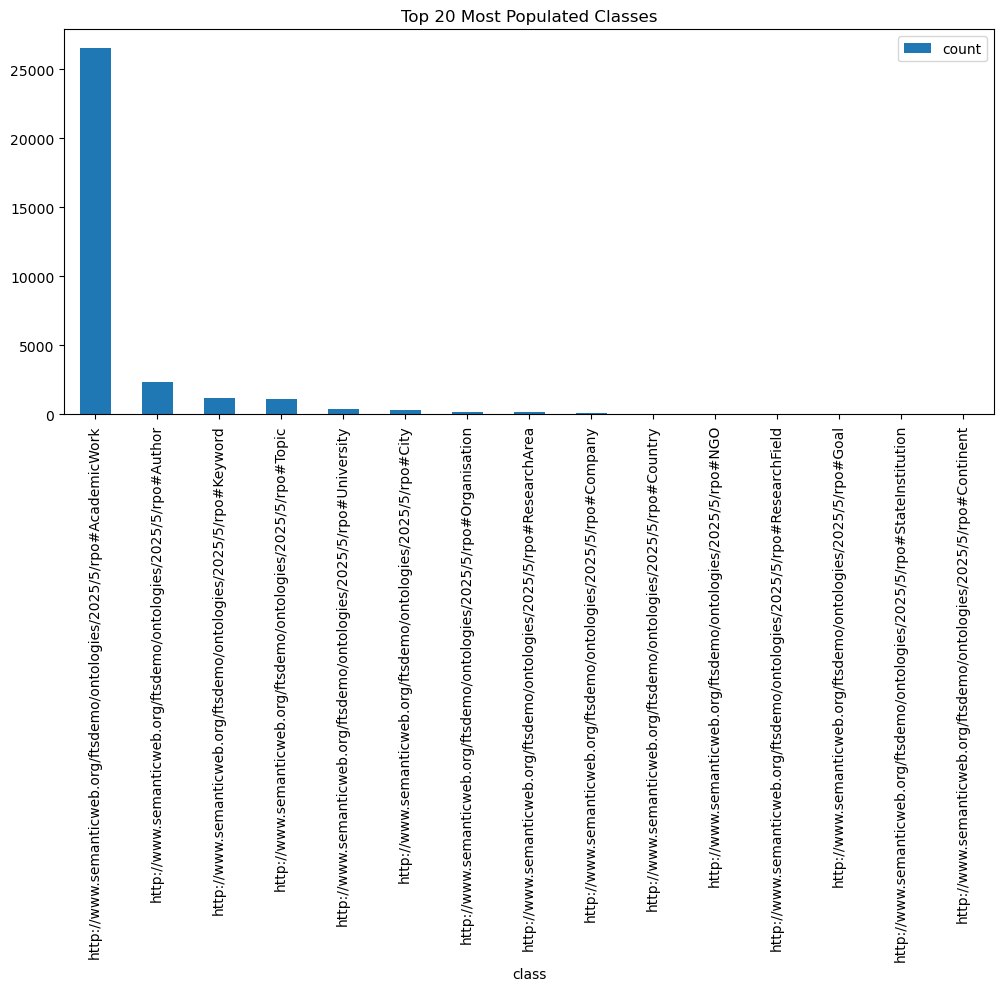

In [7]:
def q(query):
    return list(mygraph.query(query))
    
print("graph loaded with", len(mygraph), "triples\n")

query_classes = """
SELECT DISTINCT ?class WHERE {
    { ?class a owl:Class . }
    UNION
    { ?class a rdfs:Class . }
}
"""
classes = [str(row[0]) for row in q(query_classes)]
print("Found", len(classes), "classes")
classes[:20]

class_stats = []

for cls in classes:
    query_instances = f"""
    SELECT DISTINCT ?inst WHERE {{
        ?inst a <{cls}> .
    }}
    """
    instances = [str(row[0]) for row in q(query_instances)]
    class_stats.append({
        "class": cls,
        "count": len(instances),
        "sample_instances": instances[:5]   # preview 5 examples
    })

df = pd.DataFrame(class_stats).sort_values("count", ascending=False)
df
df[df["count"] > 0]
for _, row in df.iterrows():
    #if row['count'] == 0:
    #    continue
    print("============================================")
    print("CLASS:", row['class'])
    print("Instances:", row['count'])
    print("Examples:")
    for ex in row['sample_instances']:
        print("  -", ex)

df_plot = df[df["count"] > 0].head(20)  # show top 20
df_plot.plot.bar(
    x="class",
    y="count",
    figsize=(12,5),
    title="Top 20 Most Populated Classes"
)

#### Load helper functions

In [20]:
# ------------------------ GRAPH HELPERS --------------------------- #

def replace_entity(graph, old_ent, new_ent):
    triples = list(graph.triples((old_ent, None, None))) \
               + list(graph.triples((None, None, old_ent))) \

    for s, p, o in triples:
        graph.remove((s, p, o))

    for s, p, o in triples:
        s2 = new_ent if s == old_ent else s
        p2 = new_ent if p == old_ent else p
        o2 = new_ent if o == old_ent else o
        graph.add((s2, p2, o2))
        print(f"added {strip_prefix(s2)}, {strip_prefix(p2)}, {strip_prefix(o2)}")

    graph.add((old_ent, OWL.sameAs, new_ent))

def merge_entity_data(ner_graph, main_graph, entity, main_entity_type):
    for _, _, old_type in ner_graph.triples((entity, RDF.type, None)):
        if old_type != RPO.Fund:
            ner_graph.remove((entity, RDF.type, old_type))
        else:
            #main_graph.add((entity, RDF.type, RPO.Fund))
            print(f"################################ Funder detected: {strip_prefix(entity)}")
            for paper_uri in ner_graph.subjects(RPO.funded_by, entity):
                main_graph.add((paper_uri, RPO.funded_by, entity))
                print(f"added {strip_prefix(paper_uri)} funded by {strip_prefix(entity)}")
    ner_graph.add((entity, RDF.type, main_entity_type))
    main_graph.add((entity, RDF.type, correct_type))

    for paper_uri in ner_graph.subjects(RPO.mentions, entity):

        main_graph.add((paper_uri, RPO.mentions, entity))
        for sentence in ner_graph.objects(entity, RPO.observed_in_sentence):
            main_graph.add((entity, RPO.observed_in_sentence, sentence))
            
            for s, p, o in ner_graph.triples((sentence, None, None)):
                main_graph.add((s, p, o))
            
            for section in ner_graph.objects(sentence, RPO.observed_in_section):
                main_graph.add((entity, RPO.observed_in_section, section))
                main_graph.add((sentence, RPO.observed_in_section, section))
                main_graph.add((section, RDF.type, RPO.Section))

            for content in ner_graph.objects(sentence, RPO.has_content):
                main_graph.add((sentence, RPO.has_content, Literal(safety(content))))

# ---------------------- TEXT HELPERS --------------------#

import unicodedata

def safety(value):
    if isinstance(value, Literal):
        text = str(value)
    else:
        text = str(value)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def strip_prefix(uri):
    u = str(uri)
    if "#" in u:
        return u.split("#")[-1]
    return u.split("/")[-1]

def normalize(label):
    return re.sub(r'[^a-z0-9]', '', label.lower())

def to_snake(s):
    if re.fullmatch(r'[A-Z]+', s):
        return s
    s = re.sub(r'[^0-9a-zA-Z]+', ' ', s)
    s = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', s)
    s = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1_\2', s)
    s = re.sub(r'\s+', '_', s)
    return s.lower().strip('_')

def to_camel(s):
    s = re.sub(r'[^0-9a-zA-Z]+', ' ', s)
    parts = s.split()
    return ''.join(w.capitalize() for w in parts)
    


#### Load CS-KG subset relevant for the dataset and merge with the metadata graph

In [9]:
cskg = Graph()
cskg.parse("cskg_output.ttl", format = "turtle")

<Graph identifier=Nfa3b85bc184b4e71a625602bfe73d3e6 (<class 'rdflib.graph.Graph'>)>

In [10]:
CSKG = Namespace("https://w3id.org/cskg/resource/")
CSKG_ONT = Namespace("https://w3id.org/cskg/ontology#")

cskg_sameas_mg = 0
cskg_partof_mg = 0
cskg_removed = 0

cskg_class_to_entities = {}

for s, p, o in cskg.triples((None, RDF.type, None)):
    cls = o
    if cls not in cskg_class_to_entities:
        cskg_class_to_entities[cls] = set()
    cskg_class_to_entities[cls].add(s)

print("cskg graph classes and counts:")
for cls, ents in cskg_class_to_entities.items():
    print(strip_prefix(cls), "->", len(ents))

research_entities = set()
for c in [
    CSKG_ONT.Material,
    CSKG_ONT.Method,
    CSKG_ONT.Task,
    CSKG_ONT.Metric,
    CSKG_ONT.OtherEntity,
]:
    if c in cskg_class_to_entities:
        research_entities |= cskg_class_to_entities[c]

cskg graph classes and counts:
DummyClass -> 1
Entity -> 3987
Statement -> 3987
ObjectProperty -> 148
TransitiveProperty -> 46
OtherEntity -> 524
Method -> 1510
Task -> 854
Material -> 646
Metric -> 140


In [11]:
#MERGE CSKG WITH MAIN_GRAPH
main_graph.bind("cskg", CSKG)   
main_graph.bind("cskg-ont", CSKG_ONT)
main_graph.bind("prov", PROV)

cskg_counter = 0
for s, p, o in cskg.triples((None, PROV.wasDerivedFrom, None)):
    o_str = strip_prefix(str(o))
    for sub, pred, obj in main_graph.triples((None, RPO.openalex_id, None)):
        obj_str = str(obj)
        if o_str in obj_str: #trying to find a match but o is in form "W6433872389" and obj is in form "https://openalex.org/W6433872389"
            cskg.add((s, p, sub))
            print(f"Merged CSKG entity {s} into main_graph using OpenAlex ID match: {o_str}")
            cskg_counter += 1

for s, p, o in cskg.triples((None, RPO.mentions, None)):
    for doi in cskg.objects(s, RPO.doi):
        doi = doi.split('org/')[1]
    for sub, pred, obj in main_graph.triples((None, RPO.doi, None)):
        obj_str = str(obj)
        if obj_str in doi: #trying to find a match but o is in form "W6433872389" and obj is in form "https://openalex.org/W6433872389"
            cskg.add((sub, RPO.mentions, o))
            print(f"added {strip_prefix(sub)} mentions {strip_prefix(o)}")

print(cskg_counter)

Merged CSKG entity https://w3id.org/cskg/resource/statement_100113 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_21128219 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_25288644 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_40110348 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_47569087 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_49567209 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_60470288 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https://w3id.org/cskg/resource/statement_61325448 into main_graph using OpenAlex ID match: W2491251830
Merged CSKG entity https:/

#### Combine metadata and cskg and save them as a checkpoint.

In [12]:
metadata_and_cskg = main_graph + cskg
metadata_and_cskg.serialize(destination="metadata_and_cskg.ttl", format = "turtle")

<Graph identifier=N09fda466495e401394e7da0b06aa4440 (<class 'rdflib.graph.Graph'>)>

#### Clean NER entities.
The NLP pipeline is very simple, as it only uses NER from ageneral module, not fine-tuned (due to the specificity of dataset). NER entities are being compared to the existing Individuals (Institutions, Countries, Keywords, Materials) in the newly merged graph. A heurstic priority is set: entities marked as "ORG" by NER are firstly compared to the Organisations of the metadata KG. Entities marked as 'GPE' ad "LOC' are firstly compared to the Geographical entities of the metadata KG, etc. The remaining unrecognised NER entities (around 14000 out of 28000) are processed by a heuristic search looking for substrings (like "university" or "government") and further classified by DBpedia. The unclassified instances, if mentioned in a small amount of papers, are discarded. The rest joins the merged KG as an undefined concept.

In [13]:
#divide ner individuals into classes
ner_geographical = set()
ner_organisation = set()
ner_thing = set()
ner_sentence = set()
ner_section = set()

for s, p, o in ner_graph.triples((None, RDF.type, None)):
    if o == RPO.Geographical:
        ner_geographical.add(s)
    elif o == RPO.Organisation:
        ner_organisation.add(s)
    elif o == RPO.Thing:
        ner_thing.add(s)
    elif o == RPO.Sentence:
        ner_sentence.add(s)
    elif o == RPO.Section:
        ner_section.add(s)

print("NER organisations:", len(ner_organisation))
print("NER geographical:", len(ner_geographical))
print("NER thing:", len(ner_thing))

#divide main graph
class_to_entities = {}
for s, p, o in main_graph.triples((None, RDF.type, None)):
    cls = o
    if cls not in class_to_entities:
        class_to_entities[cls] = set()
    class_to_entities[cls].add(s)

print("main graph classes and counts:")
for cls, ents in class_to_entities.items():
    print(strip_prefix(cls), "->", len(ents))

topic_like = class_to_entities[RPO.Topic] | class_to_entities[RPO.Keyword] | class_to_entities[RPO.ResearchArea] | class_to_entities[RPO.ResearchField]
sorted_topic_like = sorted(topic_like, key=len, reverse=True)

main_org_like = set()
for c in [
    RPO.Organisation,
    RPO.StateInstitution,
    RPO.NGO,
    RPO.Company,
    RPO.University,
    RPO.InternationalOrganisation,
    RPO.PoliticalOrganisation
]:
    if c in class_to_entities:
        main_org_like |= class_to_entities[c]

org_like_without_org = set()
for c in [
    RPO.StateInstitution,
    RPO.NGO,
    RPO.Company,
    RPO.University,
    RPO.InternationalOrganisation,
    RPO.PoliticalOrganisation
]:
    if c in class_to_entities:
        org_like_without_org |= class_to_entities[c]

def safe_remove_type(g, subject):
    for _, _, o in list(g.triples((subject, RDF.type, None))):
        g.remove((subject, RDF.type, o))

DUMMY_NAMES = ["ntt", "universityof", "east", "universityofsouth", "ird", "lix", "total"]
sameas_links = 0
partof_links = 0
removed_ner = 0
    
for ner_org in list(ner_organisation):
    ner_name = normalize(strip_prefix(ner_org))
    matched = False
    for main_ent in org_like_without_org:
        main_name = normalize(strip_prefix(main_ent))
        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            print("specific orgs exact match:", ner_name, main_name) 
            print("added", ner_org, main_ent)
            sameas_links += 1
            #remove from the set to not process again
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:  
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            print("specific orgs match:", ner_name, main_name)
            # add part_of
            metadata_and_cskg.add((ner_org, RPO.part_of, main_ent))
            partof_links += 1
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break
            
for ner_org in list(ner_organisation):
    ner_name = normalize(strip_prefix(ner_org))
    matched = False
    for main_ent in class_to_entities[RPO.Organisation]:
        main_name = normalize(strip_prefix(main_ent))
        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            sameas_links += 1
            (f"orgs exact match {ner_name}")
            #remove from the set to not process again
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            # add part_of
            metadata_and_cskg.add((ner_org, RPO.part_of, main_ent))
            partof_links += 1
            print(f"orgs match {ner_name} {main_name}")
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_links}")
print(f"part_of links: {partof_links}")
print(f"removed ner: {removed_ner}")
"""around 28000 detected things in ner, but most of them wrongly classified"""


NER organisations: 20953
NER geographical: 2642
NER thing: 4578
main graph classes and counts:
Company -> 112
University -> 368
ObjectProperty -> 38
DatatypeProperty -> 15
AcademicWork -> 26573
City -> 343
Organisation -> 158
Author -> 2379
NGO -> 20
ResearchArea -> 138
Topic -> 1146
ResearchField -> 19
Goal -> 16
StateInstitution -> 11
Keyword -> 1211
Country -> 49
Ontology -> 1
Class -> 61
SymmetricProperty -> 1
Restriction -> 2
OtherEntity -> 1
Continent -> 6
specific orgs exact match: universityofzurich universityofzurich
added http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#UniversityOfZurich http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#UniversityofZurich
specific orgs exact match: universityofluxembourg universityofluxembourg
added http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#UniversityOfLuxembourg http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#UniversityofLuxembourg
specific orgs exact match: universityofsouthampton universityofsouthamp

'around 28000 detected things in ner, but most of them wrongly classified'

In [12]:
#metadata_and_cskg.serialize(destination="full_trial.ttl", format = "turtle")

In [19]:
DUMMY_NAMES = ["ntt", "universityof", "east", "universityofsouth", "ird", "lix", "total", "pingan", "atos"]

for cskg_ent in list(research_entities):
    cskg_name = normalize(strip_prefix(cskg_ent))

    matched = False
    
    for main_ent in main_org_like:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if cskg_name == main_name:
            replace_entity(metadata_and_cskg, cskg_ent, main_ent)
            cskg_sameas_mg += 1
            (f"re exact match {cskg_name}")
            #remove from the set to not process again
            research_entities.discard(ner_org)
            cskg_removed += 1
            matched = True
            break

        elif main_name in cskg_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            metadata_and_cskg.add((cskg_ent, RPO.part_of, main_ent))
            cskg_partof_mg += 1
            print(f"re match {cskg_name} {main_name}")
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {cskg_sameas_mg}")
print(f"part_of links: {cskg_partof_mg}")
print(f"removed ner: {cskg_removed}")

re match microsoftacademicknowledgegraph microsoft
re match europeanauthority europeana
added Amazon, type, Amazon
added W3096893124, mentions, W3096893124
added statement_20219754, subject, statement_20219754
added Siemens, type, Siemens
added statement_35876486, object, statement_35876486
added W2761748973, mentions, W2761748973
added W2512490571, mentions, W2512490571
added statement_56223106, subject, statement_56223106
added EuropeanCommission, type, EuropeanCommission
added statement_22621810, object, statement_22621810
added statement_15003711, object, statement_15003711
added W3096163455, mentions, W3096163455
added W3203673500, mentions, W3203673500
 
 ============ SUMMARY =============
sameAs links: 8
part_of links: 6
removed ner: 8


In [21]:
DUMMY_NAMES = ["ntt", "universityof", "east", "universityofsouth", "ird", "lix", "total", "pingan", "atos", "row", "art", "tec", "trie", "pace", "gene"]

for cskg_ent in list(research_entities):
    cskg_name = normalize(strip_prefix(cskg_ent))

    matched = False
    
    for main_ent in sorted_topic_like:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if cskg_name == main_name:
            replace_entity(metadata_and_cskg, cskg_ent, main_ent)
            cskg_sameas_mg += 1
            (f"re exact match {cskg_name}")
            #remove from the set to not process again
            research_entities.discard(ner_org)
            cskg_removed += 1
            matched = True
            break

        if main_name in cskg_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:

            # add part_of
            metadata_and_cskg.add((cskg_ent, RPO.part_of, main_ent))
            cskg_partof_mg += 1
            print(f"re match {cskg_name} {main_name}")
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {cskg_sameas_mg}")
print(f"part_of links: {cskg_partof_mg}")
print(f"removed ner: {cskg_removed}")

re match globalembeddings embedding
re match naturallanguageprocessingnlptask naturallanguageprocessing
re match parallelimplementationofclip implementation
re match collaborativeencyclopedia encyclopedia
added DataType, type, Method
added W2498760777, mentions, DataType
added statement_1781608, object, DataType
added statement_8196542, object, DataType
re match loddatasets dataset
re match internetofthingsiotdevice internetofthings
re match sparqlgenerate sparql
re match sparqlupdate sparql
re match pythonknowledgeembeddings embedding
re match nosqldatabase database
re match breastcancerstagingcriterion breastcancer
re match graphconvolutionalnetworksgcns graph
re match recurrenttransformer transformer
added OpenSourceSoftware, type, Method
added statement_20271897, object, OpenSourceSoftware
added W3028726450, mentions, OpenSourceSoftware
re match datatypes datatype
re match analysisofscientificpublication publication
re match dataanalyticscenario analytics
re match namedentityrecogn

In [24]:
DUMMY_NAMES = DUMMY_NAMES + ["wiki", "esco", "trie", "rust", "europe"]

sameas_cskg = 0
partof_cskg = 0

for ner_org in list(ner_organisation):
    ner_name = normalize(strip_prefix(ner_org))

    matched = False
    
    for main_ent in research_entities:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            #add sameAs
            ner_graph.add((ner_org, OWL.sameAs, main_ent))
            sameas_cskg += 1
            (f"re exact match {ner_name}")
            #remove from the set to not process again
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 3 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            # add part_of
            metadata_and_cskg.add((ner_org, RPO.part_of, main_ent))
            partof_cskg += 1
            print(f"re match {ner_name} {main_name}")
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break


print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_cskg}")
print(f"part_of links: {partof_cskg}")
print(f"removed ner: {removed_ner}")
  

re match businessprocessre businessprocess
re match knowledgehubontology ontology
re match freebasekg freebase
re match semanticwikis semanticwiki
re match provo8 provo
re match linkeddataintegrationframeworksilk9 dataintegration
re match datainterlinkingandquality linking
re match rubq20precisionk rubq
re match apachejenardf apachejena
re match interpretationoftheknowledgegraph knowledgegraph
re match jsonpath path
re match ottawabaselineinformationextraction informationextraction
re match dankerpagerank rank
re match datapropertyrangesdsd dataproperty
re match multimodalentityalignment entityalignment
re match semanticwebandaugmentedreality semanticweb
re match ganontologylearningperspective ontologylearning
re match crosslingualclassificationmodels classificationmodel
re match dataqualityvocabulary11 dataquality
re match germanfederalministryofeconomicsandtechnology economics
re match newinducingimplicitrelations inducingimplicitrelation
re match referencearchitecturemodelindustry40

In [25]:
for s, p, o in ner_graph.triples((None, RDF.type, None)):
    if o == RPO.Fund:
        ner_thing.add(s)

for ner_t in list(ner_thing):
    ner_name = normalize(strip_prefix(ner_t))

    matched = False
    
    for main_ent in sorted(research_entities, key=len, reverse=True):
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = RPO.ResearchEntity
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            #add sameAs
            metadata_and_cskg.add((ner_t, OWL.sameAs, main_ent))
            sameas_cskg += 1
            (f"re exact match {ner_name}")
            #remove from the set to not process again
            ner_thing.discard(ner_t)
            removed_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 3 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_t, RPO.part_of, main_ent))
            partof_cskg += 1
            print(f"re match {ner_name} {main_name}")
            ner_thing.discard(ner_t)
            removed_ner += 1
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_cskg}")
print(f"part_of links: {partof_cskg}")
print(f"removed ner: {removed_ner}")

re match linkingphase linking
re match visualisationmodule module
re match datalogmtl datalog
re match queryinglargeknowledgegraphs largeknowledgegraph
re match anovelpathbasedentityrelatednessmeasureforefficientcel179table4 pathbasedentityrelatednessmeasure
re match sparqlowls sparql
re match transportertask task
re match pyshexcparser15 parser
re match vectorizationmodule module
re match springernatureclassification classification
re match firstvocbench vocbench
re match googlecitation google
re match freebasedbpediadienibelungenthea freebase
re match ahybridfactcheckingapproachforknowledgegraphs knowledgegraph
re match opencitationsdatamodel461 datamodel
re match table14note table
re match dbpediawebnlgdataset dataset
re match sparqlxsdlanguage sparql
re match mathematicssubjectclassification classification
re match thisknowledgebasepopulation knowledgebase
re match sparkkgmls spark
re match parallelisedabox abox
re match html5 html
re match author54204 author
re match lubm4obda obd

In [26]:
partof_g_links = 0
sameas_g_links = 0
removed_g_ner = 0

for ner_gpe in list(ner_geographical):
    ner_name = normalize(strip_prefix(ner_gpe))

    matched = False

    for main_ent in research_entities:
        main_name = normalize(strip_prefix(main_ent))
        #exact same match
        if ner_name == main_name:
            types = list(main_graph.objects(main_ent, RDF.type))
            if types:
                correct_type = types[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_gpe, OWL.sameAs, main_ent))
            sameas_g_links += 1
            #remove from the set to not process again
            ner_geographical.discard(ner_gpe)
            print("geo exact match:", ner_name, main_name)
            removed_g_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 3 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_gpe, RPO.part_of, main_ent))
            partof_g_links += 1
            ner_geographical.discard(ner_gpe)
            removed_g_ner += 1
            print("geo match:", ner_name, main_name)
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_g_links}")
print(f"part_of links: {partof_g_links}")
print(f"removed ner: {removed_g_ner}")

geo match: qa4ieseq qa4ie
geo match: babelnet8 babelnet
geo match: dbpedia8 dbpedia
geo match: mtableaux table
geo match: m12thedistance hedis
geo match: connectivity3 connectivity
geo match: sdgs2 sdgs
geo match: inducedsubgraphs subgraph
geo match: discreted rete
geo match: bertword bert
geo match: genericsensorhandler sensor
geo match: sparqlparser sparql
geo match: saref4agri saref
geo match: hasestslicememoryp memory
geo match: subgraph2p subgraph
geo match: hornrulesrh hornrule
geo exact match: datalake datalake
geo match: adatalake datalake
geo match: sparql2sqlwiths2sml sparql
geo match: shortconversations conve
geo match: googlegeotargets12 google
geo match: microtaskworkflows task
geo match: subpath path
geo match: apachejena8 apachejena
geo exact match: oaei oaei
geo match: germandbpedia dbpedia
geo match: distlodstatscd lodstats
geo match: https http
geo match: shacl4 shacl
geo match: metapaths path
geo match: objectpropertydomain objectproperty
geo match: yagoc195 yago
geo

In [27]:
DUMMY_NAMES = ["ntt", "universityof", "east", "universityofsouth", "ird", "lix", "total", "pingan", "atos", "wiki", "esco", "trie", "als", "sion", "tec", "art", "gene", "row"]
for ner_gpe in list(ner_geographical):
    ner_name = normalize(strip_prefix(ner_gpe))

    matched = False

    for main_ent in class_to_entities[RPO.City] | class_to_entities[RPO.Country] | class_to_entities[RPO.Continent]:
        main_name = normalize(strip_prefix(main_ent))
        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_gpe, OWL.sameAs, main_ent))
            sameas_g_links += 1
            #remove from the set to not process again
            ner_geographical.discard(ner_gpe)
            print("geo exact match:", ner_name, main_name)
            removed_g_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_gpe, RPO.related_to, main_ent))
            partof_g_links += 1
            ner_geographical.discard(ner_gpe)
            removed_g_ner += 1
            print("geo match:", ner_name, main_name)
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_g_links}")
print(f"part_of links: {partof_g_links}")
print(f"removed ner: {removed_g_ner}")

geo exact match: strasbourg strasbourg
geo exact match: portugal portugal
geo exact match: minneapolis minneapolis
geo exact match: beijing beijing
geo match: metromadrid madrid
geo match: voronoi orono
geo exact match: bologna bologna
geo exact match: estonia estonia
geo match: acrossafrica africa
geo exact match: venezuela venezuela
geo exact match: brest brest
geo match: grandduchyoffinland finland
geo exact match: czechia czechia
geo match: unitedstatesofamerica unitedstates
geo exact match: tripoli tripoli
geo exact match: philadelphia philadelphia
geo exact match: rostock rostock
geo match: bielefeldt bielefeld
geo match: cityoflondon london
geo exact match: milan milan
geo match: midwesternunitedstates unitedstates
geo exact match: japan japan
geo exact match: cologne cologne
geo exact match: ulm ulm
geo exact match: india india
geo match: beijingcity beijing
geo exact match: ireland ireland
geo exact match: saudiarabia saudiarabia
geo match: eplerenone reno
geo exact match: osl

In [28]:
sameas_t_links = 0
partof_t_links = 0
removed_t_ner = 0

for ner_t in list(ner_thing):
    ner_name = normalize(strip_prefix(ner_t))

    matched = False
    
    for main_ent in org_like_without_org:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            print("weird orgs exact match:", ner_name, main_name)
            #add sameAs
            metadata_and_cskg.add((ner_t, OWL.sameAs, main_ent))
            sameas_t_links += 1

            #remove from the set to not process again
            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            print("weird orgs match:", ner_name, main_name)

            # add part_of
            metadata_and_cskg.add((ner_t, RPO.part_of, main_ent))
            partof_t_links += 1

            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break
            
for ner_t in list(ner_thing):
    ner_name = normalize(strip_prefix(ner_t))

    matched = False
    for main_ent in class_to_entities[RPO.Organisation]:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            #add sameAs
            metadata_and_cskg.add((ner_t, OWL.sameAs, main_ent))
            sameas_t_links += 1
            (f"orgs exact match {ner_name}")
            #remove from the set to not process again
            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            # add part_of
            metadata_and_cskg.add((ner_t, RPO.part_of, main_ent))
            partof_t_links += 1
            print(f"orgs match {ner_name} {main_name}")
            ner_organisation.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_t_links}")
print(f"part_of links: {partof_t_links}")
print(f"removed ner: {removed_t_ner}")

weird orgs match: europecenterofstanforduniversity stanforduniversity
weird orgs exact match: tsinghuauniversity tsinghuauniversity
weird orgs match: springernature2018a springernature
weird orgs match: microsoftazureforresearchaward microsoft
weird orgs exact match: alleninstituteforartificialintelligence alleninstituteforartificialintelligence
weird orgs match: springernature2018abackground springernature
weird orgs match: springernature2018 springernature
weird orgs exact match: atos atos
weird orgs match: springernature2018aquestion springernature
weird orgs exact match: rwthaachenuniversity rwthaachenuniversity
weird orgs exact match: springernature springernature
weird orgs exact match: freeuniversityofbozenbolzano freeuniversityofbozenbolzano
weird orgs match: applenoisecancelheadphones apple
weird orgs match: springernature2018agroupwork springernature
weird orgs match: microsoftresearch microsoft
weird orgs exact match: thales thales
weird orgs match: springernature2018anoneth

In [29]:
for ner_t in list(ner_thing):
    ner_name = normalize(strip_prefix(ner_t))

    matched = False
    for main_ent in sorted_topic_like:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_t, OWL.sameAs, main_ent))
            sameas_t_links += 1
            (f"topics exact match {ner_name}")
            #remove from the set to not process again
            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break
            
        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:

            if main_name =="spar" and "sparql" in ner_name:
                main_name = "sparql"
                main_ent = RPO["Sparql"]
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_t, RPO.part_of, main_ent))
            partof_t_links += 1
            print(f"topics match {ner_name} {main_name}")
            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_t_links}")
print(f"part_of links: {partof_t_links}")
print(f"removed ner: {removed_t_ner}")

topics match internationalconferenceoncomputationallinguistics linguistics
topics match globaldatabaseofeventslanguageandtone database
topics match lodgingbusiness business
topics match listeningexperiencedatabaseled database
topics match invoicecontent invoice
topics match keyperformanceindicator performanceindicator
topics match algorithm1start algorithm
topics match schoenbergdatabase database
topics match novelty0717 novelty
topics match malgorithm5 algorithm
topics match prefixspan prefix
topics match templatecorrectnesstc correctness
topics match lawnornaments law
topics match algorithm1one algorithm
topics match theoryofcomputation computation
topics match worldinputoutputdatabase database
topics match nobelprizeinphysics physics
topics match algorithm1 algorithm
topics match semevalabsa semeval
topics match daadgermanacademicexchange german
topics match f1business business
topics match graphsage graph
topics match roaringbitmaps bitmap
topics match cadaster4 cad
topics match st

In [30]:
DUMMY_NAMES = DUMMY_NAMES + ["basel", "turin", "dublin", "jena", "denmark", "ume", "reno"]

for ner_t in list(ner_thing):
    ner_name = normalize(strip_prefix(ner_t))

    matched = False
    for main_ent in class_to_entities[RPO.City] | class_to_entities[RPO.Country] | class_to_entities[RPO.Continent]:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_t, OWL.sameAs, main_ent))
            sameas_t_links += 1
            (f"geo exact match {ner_name}")
            #remove from the set to not process again
            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break
            
#mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_t, RPO.related_to, main_ent))
            partof_t_links += 1
            print(f"geo match {ner_name} {main_name}")
            ner_thing.discard(ner_t)
            removed_t_ner += 1
            matched = True
            break

print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_t_links}")
print(f"part_of links: {partof_t_links}")
print(f"removed ner: {removed_t_ner}")

geo match researchcouncilofnorway norway
geo match fwfaustriansciencefund austria
geo match nuigalway galway
geo match austrianfederalministryoftransportinnovationandtechnology austria
geo match airasiazest asia
geo match capitalsinasia asia
geo match oxfordsemantictechnologies oxford
geo match netherlandsorganisationforscientificresearch netherlands
geo match airasiaflight8501 asia
geo match databenchnorway norway
geo match actionplanforinnovationonscienceandtechnologyprojectsofshanghai shanghai
geo match notredamedeparis paris
geo match viennascienceandtechnologyfund vienna
geo match europeanopensciencecloud europe
geo match europeancommunitys europe
geo match naturalsciencefoundationofchina china
geo match nationalnaturalsciencefoundationofchina china
geo match cityofvienna vienna
geo match programofchina china
geo match newtechnologiesforthemadeinitaly italy
geo match europeanparliamentelection europe
geo match tianjinthousandyoungtalentsprogram tianjin
geo match idexparissaclay pa

In [31]:
DUMMY_NAMES = DUMMY_NAMES + ['lige']

for ner_org in list(ner_organisation):
    ner_name = normalize(strip_prefix(ner_org))

    matched = False
    
    for main_ent in class_to_entities[RPO.City] | class_to_entities[RPO.Country] | class_to_entities[RPO.Continent]:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_org, OWL.sameAs, main_ent))
            sameas_links += 1
            (f"orgs exact match {ner_name}")
            #remove from the set to not process again
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Organisation
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_org, RPO.related_to, main_ent))
            partof_links += 1
            print(f"orgs match {ner_name} {main_name}")
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break


print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_links}")
print(f"part_of links: {partof_links}")
print(f"removed ner: {removed_ner}")

orgs match romearchaeologicalarea rome
orgs match englishrussian russia
orgs match europeantransportindustry europe
orgs match australiandigitaltransformation australia
orgs match universityofmelbourne melbourne
orgs match intelligentriskmanagement lige
orgs match generalbathymetricchart bath
orgs match comparisonofdatastructurestomanage paris
orgs match abfaustraliabushfire australia
orgs match tboxtexafromexample2 rome
orgs match milanodesign milan
orgs match philharmoniedeparispphave paris
orgs match stanfordcoref stanford
orgs match indian india
orgs match nationalobservatoryofathens athens
orgs match europeandsi europe
orgs match bsdetectorchromeextension rome
orgs match indiatodayin india
orgs match ghentaltarpiece ghent
orgs match bibliothequenationaledefrance france
orgs match austrian austria
orgs match radiofrance france
orgs match imecandinteroperableeurope europe
orgs match chinaexpress china
orgs match airasia asia
orgs match unitedstatescongresses unitedstates
orgs match 

In [58]:
DUMMY_NAMES += ["tec"]

for ner_org in list(ner_organisation):
    ner_name = normalize(strip_prefix(ner_org))

    matched = False
    
    for main_ent in sorted_topic_like:
        main_name = normalize(strip_prefix(main_ent))

        #exact same match
        if ner_name == main_name:
            correct_type = list(main_graph.objects(main_ent, RDF.type))[0]
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_org, OWL.sameAs, main_ent))
            sameas_links += 1
            (f"topics exact match {ner_name}")
            #remove from the set to not process again
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break

        #mygraph name in ner name
        if main_name in ner_name and len(main_name) > 2 and main_name not in DUMMY_NAMES:
            correct_type = RPO.Concept
            merge_entity_data(ner_graph, metadata_and_cskg, ner_org, correct_type)
            metadata_and_cskg.add((ner_org, RPO.part_of, main_ent))
            partof_links += 1
            print(f"topics match {ner_name} {main_name}")
            ner_organisation.discard(ner_org)
            removed_ner += 1
            matched = True
            break


print(" \n ============ SUMMARY =============")
print(f"sameAs links: {sameas_links}")
print(f"part_of links: {partof_links}")
print(f"removed ner: {removed_ner}")

topics match diseasedrug disease
topics match nationalclearinghouseonautismevidence autism
topics match germankg german
topics match openmeetingssystemmeetingmanagement management
topics match bibliographicdatatriplification graph
topics match semeval20173 semeval
topics match publishingld publishing
topics match fileextractors extractor
topics match sentencepiece sentence
topics match activitystreams streams
topics match partialtransitiveclosure transitiveclosure
topics match gnugeneralpubliclicense license
topics match xmlinfoset xml
topics match creativecommonsattributionshare attribution
topics match algorithmbasic algorithm
topics match joinsequences joins
topics match socialdemographyresearchusingsemantictechnologies211limitations demography
topics match consortium41 sort
topics match knowledgecardextractor extractor
topics match publishingwithoutpublishers publishing
topics match multimediaand multimedia
topics match sgraph graph
topics match verizoncommunications communication


In [33]:
for s, p, o in ner_graph.triples((None, RDF.type, None)):
    if o == RPO.Fund:
        correct_type = RPO.Fund
        merge_entity_data(ner_graph, metadata_and_cskg, s, correct_type)

################################ Funder detected: 01IS21084
added paper/931 funded by 01IS21084
################################ Funder detected: 01QE2114B
added paper/954 funded by 01QE2114B
################################ Funder detected: 3dfed
added paper/943 funded by 3dfed
################################ Funder detected: 7thH2020Programmes
added paper/492 funded by 7thH2020Programmes
################################ Funder detected: 973Program
added paper/658 funded by 973Program
################################ Funder detected: ANID
added paper/1072 funded by ANID
################################ Funder detected: ATOS
added paper/153 funded by ATOS
################################ Funder detected: Affairs
added paper/815 funded by Affairs
################################ Funder detected: AirForceResearchLaboratory
added paper/487 funded by AirForceResearchLaboratory
################################ Funder detected: AkkodisGroup
added paper/433 funded by AkkodisGroup
###########

In [34]:
print("len of remaining ner orgs", len(ner_organisation))
print("len of remaining ner geo", len(ner_geographical))
print("len of remaining ner things", len(ner_thing))

len of remaining ner orgs 15869
len of remaining ner geo 2229
len of remaining ner things 3359


#### Processing remaining NER entities
If there was no (partial) match between NER entities and CSKG+metadata entities, it's probable that the NER entity is rare or noisy. We are applying a heuristic search to determine whether there are any organisations or geographical entities remaining in the NER set. For the remaining entities, we will exclude every individual which is only mentioned in one paper (low statistical weight). The chosen NER entities will be classified via a Wikidata search.

In [36]:
from collections import defaultdict

ner_new_gov = set()
ner_new_uni = set()
ner_new_geo = set()
ner_remaining = ner_thing | ner_organisation | ner_geographical

#heuristic: keywords for loose categorisation
gov_keywords = ["government", "federal", "ministry", "administra", "govern", "stateinst", "national"]
university_keywords = ["university", "college", "institut", "science", "research",  "museum", "group", "academy", "system", "foundation"]
countries = [
    "afghanistan","albania","algeria","andorra","angola","antiguaanbarbuda","argentina",
    "armenia","australia","austria","azerbaijan","bahamas","bahrain","bangladesh","barbados",
    "belarus","belgium","belize","benin","bhutan","bolivia","bosniaandherzegovina",
    "botswana","brazil","brunei","bulgaria","burkinafaso","burundi","caboverde","cambodia",
    "cameroon","canada","centralafricanrepublic","chad","chile","china","colombia","comoros",
    "congo","costarica","croatia","cuba","cyprus","czechrepublic","democraticrepublicofthecongo",
    "denmark","djibouti","dominica","dominicanrepublic","ecuador","egypt","elsalvador",
    "equatorialguinea","eritrea","estonia","eswatini","ethiopia","fiji","finland","france",
    "gabon","gambia","georgia","germany","ghana","greece","grenada","guatemala","guinea",
    "guineabissau","guyana","haiti","honduras","hungary","iceland","india","indonesia",
    "iran","iraq","ireland","israel","italy","jamaica","japan","jordan","kazakhstan",
    "kenya","kiribati","kuwait","kyrgyzstan","laos","latvia","lebanon","lesotho","liberia",
    "libya","liechtenstein","lithuania","luxembourg","madagascar","malawi","malaysia",
    "maldives","mali","malta","marshallislands","mauritania","mauritius","mexico",
    "micronesia","moldova","monaco","mongolia","montenegro","morocco","mozambique","myanmar",
    "namibia","nauru","nepal","netherlands","newzealand","nicaragua","niger","nigeria",
    "northkorea","northmacedonia","norway","oman","pakistan","palau","palestine", "panama",
    "papuanewguinea","paraguay","peru","philippines","poland","portugal","qatar","romania",
    "russia","rwanda","saintkittsandnevis","saintlucia","saintvincentandthegrenadines",
    "samoa","sanmarino","saotomeandprincipe","saudiarabia","senegal","serbia","seychelles",
    "sierraleone","singapore","slovakia","slovenia","solomonislands","somalia","southafrica",
    "southkorea","southsudan","spain","srilanka","sudan","suriname","sweden","switzerland",
    "syria","taiwan","tajikistan","tanzania","thailand","timorleste","togo","tonga",
    "trinidadandtobago","tunisia","turkey","turkmenistan","tuvalu","uganda","ukraine",
    "unitedarabemirates","unitedkingdom","unitedstates","uruguay","uzbekistan","vanuatu",
    "vaticancity","venezuela","vietnam","yemen","zambia","zimbabwe"
]


for ner in list(ner_remaining):
    if any(keyword in strip_prefix(ner).lower() for keyword in gov_keywords):
        #print(f"{strip_prefix(ner)} added to ner_new_gov")
        ner_new_gov.add(ner)
        ner_remaining.discard(ner)
    elif any(keyword in strip_prefix(ner).lower() for keyword in university_keywords):
        #print(f"{strip_prefix(ner)} added to ner_new_uni")
        ner_new_uni.add(ner)
        ner_remaining.discard(ner)
    elif any(keyword in strip_prefix(ner).lower() for keyword in countries):
        #print(f"{strip_prefix(ner)} added to ner_new_geo")
        ner_new_geo.add(ner)
        ner_remaining.discard(ner)

print("gov", len(ner_new_gov))
print("uni", len(ner_new_uni))
print("geo", len(ner_new_geo))
print("remaining", len(ner_remaining))
print("=================================================")

#look for "popular" mentions:

mentions_per_entity = defaultdict(set)
for paper, p, ent in ner_graph.triples((None, RPO.mentions, None)):
    mentions_per_entity[ent].add(paper)

popular = set()
for ner in list(ner_remaining):
    if len(mentions_per_entity.get(ner, [])) > 1:
        popular.add(ner)
        ner_remaining.discard(ner)
        print(ner)

print("popular", len(popular))
print("total remaining", len(ner_remaining))

gov 217
uni 526
geo 138
remaining 20572
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#KolmogorovSmirnov
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Model1
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Stage2
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#RdfHdt
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Approach1
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Llama2
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Laser1
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Ccby40
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Algorithm1
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Round4
popular 10
total remaining 20562


In [62]:
import requests
import time
import json

def camel_to_readable(camel_str):
    result = []
    for i, char in enumerate(camel_str):
        if char.isupper() and i > 0:
            result.append(' ')
        result.append(char)
    return ''.join(result)

def get_wikidata_types(entities):

    results = {}
    
    for entity in entities:
        search_term = camel_to_readable(entity)
        print(f"Processing: {entity} -> searching as '{search_term}'")
        
        try:
            search_url = "https://www.wikidata.org/w/api.php"
            params = {
                'action': 'wbsearchentities',
                'search': search_term,
                'language': 'en', 
                'format': 'json',
                'limit': 1
            }
            
            headers = {
                'User-Agent': 'Mozilla/5.0 (compatible; WikidataTypeFinder/1.0)'
            }
            
            response = requests.get(search_url, params=params, headers=headers, timeout=15)
            data = response.json()
            
            if not data.get('search'):
                results[entity] = {'type': 'Entity not found'}
                continue
            
            entity_id = data['search'][0]['id']
            entity_label = data['search'][0].get('label', 'No label')
            print(f"  Found: {entity_label} (ID: {entity_id})")
            
            #entity info with SPARQL query
            sparql_query = """
            SELECT ?type ?typeLabel WHERE {
              wd:%s wdt:P31 ?type .
              SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
            }
            LIMIT 1
            """ % entity_id
            
            sparql_url = "https://query.wikidata.org/sparql"
            sparql_params = {
                'format': 'json',
                'query': sparql_query
            }
            
            sparql_response = requests.get(sparql_url, params=sparql_params, headers=headers, timeout=15)
            sparql_data = sparql_response.json()
            
            # results
            bindings = sparql_data['results']['bindings']
            
            if bindings:
                type_label = bindings[0].get('typeLabel', {}).get('value', 'Type not found')
                
                results[entity] = {
                    'wikidata_label': entity_label,
                    'type': type_label,
                }
                print(f"  types: {type_label}")
            else:
                results[entity] = {
                    'wikidata_label': entity_label,
                    'type': 'No types found'
                }
                print(f"  No types found")
                
        except Exception as e:
            print(f"  Error: {str(e)}")
            results[entity] = {'type': f'Error'}
        
        print("  sleep 1 s")
        time.sleep(0.2)
    
    return results

# =============== USE ==================================
"""
qualified_ner = ner_new_gov | ner_new_geo | ner_new_uni | popular

qualified_dict = {}

for ent in qualified_ner:
    qualified_dict[strip_prefix(ent)] = ent

results = get_wikidata_types(list(qualified_dict.keys()))
    
print("\n" + "="*60)
print("FINAL RESULTS:")
print("="*60)
for entity, info in results.items():
    print(f"{entity}:")
    if 'wikidata_label' in info:
        print(f"  Wikidata label: {info['wikidata_label']}")
    print(f"  Type: {info['type']}")
    print(f"  Superclass: {info['superclass']}")
    print()
"""


Processing: Fuelsystem -> searching as 'Fuelsystem'
  Not found with spaces, trying with underscores: 'Fuelsystem'
Processing: EnterpriseCollaborationSystems -> searching as 'Enterprise Collaboration Systems'
  Found: Enterprise Collaboration Systems: An Analysis and Classification of Adoption Challenges (ID: Q58003143)
  No types found
  sleep 1 s
Processing: SiriusCentreNorweGianResearchCouncil -> searching as 'Sirius Centre Norwe Gian Research Council'
  Not found with spaces, trying with underscores: 'Sirius_Centre_Norwe_Gian_Research_Council'
Processing: BlackboardSystems -> searching as 'Blackboard Systems'
  Not found with spaces, trying with underscores: 'Blackboard_Systems'
Processing: EResearch -> searching as 'E Research'
  Found: E-research (ID: Q5321542)
  No types found
  sleep 1 s
Processing: EarthScience -> searching as 'Earth Science'
  Found: Earth science (ID: Q8008)
  types: field of study, superclass topic
  sleep 1 s
Processing: HadoopDistributedFilesysTem -> sear

In [63]:
# PROCESS GATHERED TYPES
distinct_types = []
distinct_superclasses = []
for entity, info in results.items():
    if info.get("type") not in distinct_types:
        distinct_types.append(info.get("type"))
    if info.get("superclass") not in distinct_superclasses:
        distinct_superclasses.append(info.get("superclass"))

print(len(distinct_types), distinct_types)
print(len(distinct_superclasses), distinct_superclasses)

CATEGORY_MAP = {
    "PoliticalOrganisation": ["political", "cabinet", "party"],             # government agency
    "University": ["university", "education", "academic"],
    "Organisation": ["organization", "museum", "bank", "library", "institute", "society", "hospital", "national"],
    "StateInstitution": ["govern", "ministry", "agency"],
    "NGO": ["nonprofit", "charitable"],
    "Company": ["airline", "business", "company", "corporation"],
    "Geographical": ["state", "mountain", "language", "park"],
    "OtherEntity": ["work", "database", "dataset", "registry", "technical", "software", "metric"] }

COUNTRY = {"Country": ["country"]}
 
counter_merger = 0

"""def contains_keyword(entity_label: str, keywords: list[str]):
    low = entity_label.lower()
    return any(kw in low for kw in keywords)

#print(results)


for entity, info in results.items():    
    entity_label = entity
    resolved_uri = qualified_dict.get(entity)

    matched = False
    for category, keywords in CATEGORY_MAP.items():
        if contains_keyword(info["type"]+" "+info["superclass"]+str(entity_label), keywords):
            correct_type = getattr(RPO, category)
            merge_entity_data(ner_graph, metadata_and_cskg, resolved_uri, correct_type)
            counter_merger += 1
            print(counter_merger, "added", {entity_label}, "match on", getattr(RPO, category))
            matched = True
            break

    keywords = COUNTRY["Country"]
    if resolved_uri in ner_new_geo:
        if contains_keyword(str(info["type"]), keywords):
            correct_type = RPO.Country
            merge_entity_data(ner_graph, metadata_and_cskg, resolved_uri, correct_type)
            counter_merger += 1
            print(counter_merger, "added", {entity_label}, "match on", "Country")
            continue
        elif not matched:
            correct_type = RPO.Organisation
            merge_entity_data(ner_graph, metadata_and_cskg, resolved_uri, correct_type)
            counter_merger += 1
            print(counter_merger, "added", {entity_label}, "no match on country, added ORG",)
            matched = True
            

    if not matched:
        correct_type = RPO.Concept
        merge_entity_data(ner_graph, metadata_and_cskg, resolved_uri, correct_type)
        print("No category match for:", entity_label, "added as Concept")

"""

136 ['Entity not found', 'No types found', 'field of study', 'government', 'academic library', 'country', 'United States patent', 'museum', 'national library', 'natural language', 'academic journal', 'conference proceedings series', 'content delivery network', 'research institute', 'academic conference series', 'Wikinews article', 'university', 'aptitude', 'tram stop', 'organization', 'television program', 'human population', 'central bank', 'community and regional governments', 'type of organization', 'scientific journal', 'type of position', 'government agency', 'national park', 'speculative fiction genre', 'type of museum', 'business', 'class of disease', 'ministry of digital policy', 'geological formation', 'ministry of Italy', 'learned society', 'nonprofit organization', 'ministry of science', 'musical group', 'closed project', 'non-governmental organization', 'federal government', 'foundation', 'land-grant university', 'financial institution', 'taxon', 'modern language', 'economi

In [ ]:
import requests
import time
import re

def split_cap_sequences(s):
    s = re.sub(r'^\d+|\d+$', '', s)
    if s.isupper():
        return s
    def split_caps(m):
        seq = m.group(0)
        return seq[:-1] + ' ' + seq[-1]
    s = re.sub(r'[A-Z]{2,}(?=[A-Z][a-z]|[a-z])', split_caps, s)
    s = re.sub(r'(?<=[a-z])([A-Z])', r' \1', s)
    return re.sub(r'\s+', ' ', s).strip()

def camel_to_readable(s):
    s = re.sub(r'^\d+|\d+$', '', s)
    if s.isupper():
        return s
    s = split_cap_sequences(s)
    out = []
    for i, c in enumerate(s):
        if c.isupper() and i > 0 and not s[i-1].isupper():
            out.append(" ")
        out.append(c)
    return re.sub(r'\s+', ' ', ''.join(out))

def check_wikidata_entities(entities):
    counter = 0
    results = {}

    for entity in entities:
        counter += 1
        if counter % 100 == 0:
            print(f"================================= processed {counter} out of {len(entities)} entities")

        term = camel_to_readable(strip_prefix(entity))

        try:
            url = "https://www.wikidata.org/w/api.php"
            headers = {'User-Agent': 'Mozilla/5.0'}

            params = {
                'action': 'wbsearchentities',
                'search': term,
                'language': 'en',
                'format': 'json',
                'limit': 1
            }

            r = requests.get(url, params=params, headers=headers, timeout=10)
            data = r.json()
            search_results = data.get("search", [])

            if not search_results:
                alt = re.sub(r"(the |for |of |and |dela |de )", " ", term)
                params['search'] = alt
                r = requests.get(url, params=params, headers=headers, timeout=10)
                data = r.json()
                search_results = data.get("search", [])

            if not search_results:
                results[entity] = False
                print(f"{entity} not found")
                time.sleep(0.3)
                continue

            qid = search_results[0]["id"]

            params_claims = {
                'action': 'wbgetclaims',
                'entity': qid,
                'property': 'P31',
                'format': 'json'
            }

            r = requests.get(url, params=params_claims, headers=headers, timeout=10)
            claims_data = r.json()

            has_type = "P31" in claims_data.get("claims", {})
            results[entity] = has_type

            print(f"{entity} => {'has type' if has_type else 'exists but NO TYPE'}")

        except:
            results[entity] = False
            print(f"{entity} error / not found")

        time.sleep(0.1)

    return results

qualified = ner_remaining | popular | ner_new_geo | ner_new_gov | ner_new_uni

ner_wikidata_accepted = check_wikidata_entities(qualified)

http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#FFN => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#CybersecurityP2 => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Aka => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#1GigabitEthernet => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#SDN => exists but NO TYPE
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#SoMohse not found
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Yerusha => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Esv => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#AdaptCentre => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#CFQ => has type
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#PsOts not found
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#Schemeex not found
http://www.semanticweb.org/ftsdemo/ontologies/2025/5/rpo#OpenDigitalRigh

In [42]:
keywords = ["airforce", "navy", "police"]
for s, p, o in metadata_and_cskg.triples((None, RDF.type, None)):
    if any(keyword in strip_prefix(s).lower() for keyword in keywords):
        print(strip_prefix(s))
        metadata_and_cskg.add((s, RDF.type, RPO.MilitaryOrganisation))
    

USAirForceResearchLaboratoryInformationDirectorate
UnitedStatesAirForceResearchLaboratory
UnitedStatesNavy
AirForceResearchLaboratory
UnitedStatesAirForce
USAirForceResearchLaboratoryInformationDirectorate
UnitedStatesAirForceResearchLaboratory
UnitedStatesNavy
AirForceResearchLaboratory
UnitedStatesAirForce


In [43]:
t = 0
f = 0
for entity, value in ner_wikidata_accepted.items():
    if value:
        t += 1
        correct_type = RPO.Concept
        merge_entity_data(ner_graph, metadata_and_cskg, entity, correct_type)
        if t % 100 == 0:
            print("===========================================", t, " added entities =============================================")
    else:
        f += 1

print(f"added {t} entities as Conept, discarded {f} entities")
        

################################ Funder detected: RegioneLombardia
added paper/83 funded by RegioneLombardia
=========================================== 100  added entities =============================================
=========================================== 200  added entities =============================================
=========================================== 300  added entities =============================================
=========================================== 400  added entities =============================================
################################ Funder detected: CNRS
added paper/512 funded by CNRS
=========================================== 500  added entities =============================================
################################ Funder detected: NationalBasicResearchProgram
added paper/67 funded by NationalBasicResearchProgram
=========================================== 600  added entities =============================================
############

In [46]:
metadata_and_cskg.serialize(destination="full_trial_cleaned.ttl", format = "turtle")

<Graph identifier=N09fda466495e401394e7da0b06aa4440 (<class 'rdflib.graph.Graph'>)>

In [48]:
dupl = metadata_and_cskg

for s, p, o in dupl.triples((None, None, None)):
    su = strip_prefix(s)
    if "/" in su:
        dupl.remove((s, p, o))
        dupl.add((RPO[su.replace("/", "")], p, o))
        print(su.replace("/", ""))

dupl.serialize(destination="full_trial_cleaned_2.ttl", format = "turtle")

paper466sent1858
paper541sent4604
paper1058sent7048
paper100sent295
paper399sent4670
paper821sent4238
paper1000sent1823
paper406sent1012
paper975sent836
paper1064sent1548
paper680sent151
paper950sent3748
paper835sent1841
paper101sent3168
paper915sent510
paper24
paper988sent10058
paper71sent2092
paper584sent625
paper446sent7810
paper1011sent231
paper317sent514
paper1004sent814
paper1048sent3113
paper991sent1123
paper918sent1172
paper509sent3055
paper664sent2537
paper803sent8027
paper466sent2174
paper1060sent2427
paper383sent990
paper657sent2699
paper663
paper616
paper895sent7603
paper1038sent3650
paper1008sent1875
paper254sent1127
paper120sent2877
paper633sent3693
paper724sent685
paper114sent2275
paper435sent1842
paper1008sent857
paper754
paper167
paper111sent2375
paper753
paper1043sent1428
paper397sent1492
paper722sent399
paper79sent4531
paper867sent353
paper1008sent528
paper789sent1272
paper874sent8325
paper847sent1949
paper870sent1842
paper95sent3575
paper47sent774
paper681sent1410
p

<Graph identifier=N09fda466495e401394e7da0b06aa4440 (<class 'rdflib.graph.Graph'>)>

In [49]:
from urllib.parse import urlparse

def strip_leading_digits(local):
    return re.sub(r'^\d+', '', local)

def fix_uri(uri):
    s =str(uri)
    parsed = urlparse(s)

    if "#" in s:
        ns, local = s.rsplit("#", 1)
        separator = "#"
    else:
        ns, local = s.rsplit("/", 1)
        separator = "/"

    if local and local[0].isdigit():
        new_local = strip_leading_digits(local)
        if new_local == "":
            new_local = "Entity"
        return URIRef(ns + separator + new_local)

    return uri

def fix_numeric_entities(g):
    new_g = Graph()
    new_g.bind("rpo", RPO)
    new_g.bind("cskg", CSKG)
    new_g.bind("prov", PROV)
    new_g.bind("cskg-ont", CSKG_ONT)

    for s, p, o in g:
        new_s = fix_uri(s) if isinstance(s, URIRef) else s
        new_p = fix_uri(p) if isinstance(p, URIRef) else p
        new_o = fix_uri(o) if isinstance(o, URIRef) else o
        new_g.add((new_s, new_p, new_o))
    return new_g

clean_g = fix_numeric_entities(dupl)
clean_g.serialize("full_trial_cleaned3.ttl", format = "turtle")

<Graph identifier=N776b9c1f4b4c49698e05802afe03ea1d (<class 'rdflib.graph.Graph'>)>

In [50]:
def remove_duplicates(graph):
    unique_triples = set()
    to_remove = []

    for s, p, o in graph.triples((None, None, None)):
        triple = (s, p, o)
        if triple in unique_triples:
            to_remove.append(triple)
        else:
            unique_triples.add(triple)

    for s, p, o in to_remove:
        graph.remove((s, p, o))

    return graph

remove_duplicates(clean_g).serialize("full_trial_cleaned4.ttl", format = "turtle")

<Graph identifier=N776b9c1f4b4c49698e05802afe03ea1d (<class 'rdflib.graph.Graph'>)>

In [94]:
"""import urllib.parse
import unicodedata

illegal = re.compile(r"[^A-Za-z0-9\-\._~!$&'()*+,;=:@/?#]")

def simplify_name(name: str) -> str:
    name = unicodedata.normalize("NFD", name)
    name = name.encode("ascii", "ignore").decode("utf-8")
    name = re.sub(r'[^A-Za-z0-9_]', '', name)
    return name

def sanitize_rpo_iri(iri: URIRef, rpo_ns: str) -> URIRef:
    iri_str = str(iri)
    if iri_str.startswith(rpo_ns):
        local = iri_str[len(rpo_ns):]
        local_clean = simplify_name(local)
        return URIRef(f"{rpo_ns}{local_clean}")
    else:
        return iri  # leave other namespaces untouched

new = Graph()
new.bind("rpo", RPO)
new.bind("cskg", CSKG)
new.bind("prov", PROV)
new.bind("cskg-ont", CSKG_ONT)

for s, p, o in clean_g:
    s2 = sanitize_rpo_iri(s, str(RPO)) if isinstance(s, URIRef) else s
    p2 = sanitize_rpo_iri(p, str(RPO)) if isinstance(p, URIRef) else p
    o2 = sanitize_rpo_iri(o, str(RPO)) if isinstance(o, URIRef) else o
    new.add((s2, p2, o2))

new.serialize(destination="full_trial_cleaned.ttl", format="turtle")
print("Saved cleaned TTL")"""


Saved cleaned TTL
